In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)

import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [18]:
df = pd.read_csv("tweets.csv")

df = df[['text', 'target']]
df['text'] = df['text'].fillna('')

In [19]:
X = df['text']
y = df['target']

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [21]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_main_tfidf = tfidf.fit_transform(X_train_main)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)


In [22]:
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 50],
        'solver': ['lbfgs']
    },
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    }
]

grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_main_tfidf, y_train_main)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [23]:
y_test_probs = best_model.predict_proba(X_test_tfidf)[:, 1]
y_val_probs = best_model.predict_proba(X_val_tfidf)[:, 1]

# =========================
# DEFAULT THRESHOLD
# =========================
y_pred_default = (y_test_probs >= 0.5).astype(int)

print("\nDEFAULT RESULTS")
print(classification_report(y_test, y_pred_default))



DEFAULT RESULTS
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      1851
           1       0.60      0.74      0.67       423

    accuracy                           0.86      2274
   macro avg       0.77      0.82      0.79      2274
weighted avg       0.88      0.86      0.87      2274



In [24]:
thresholds = np.linspace(0.05, 0.95, 200)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best F1 (Validation):", best_f1)



Best Threshold: 0.5610552763819096
Best F1 (Validation): 0.6606606606606606


In [25]:
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("\nFINAL RESULTS")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


FINAL RESULTS
Accuracy: 0.8715919085312225
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1851
           1       0.65      0.66      0.66       423

    accuracy                           0.87      2274
   macro avg       0.79      0.79      0.79      2274
weighted avg       0.87      0.87      0.87      2274



In [26]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


Confusion Matrix:
 [[1704  147]
 [ 145  278]]


ROC-AUC: 0.9046359197571309


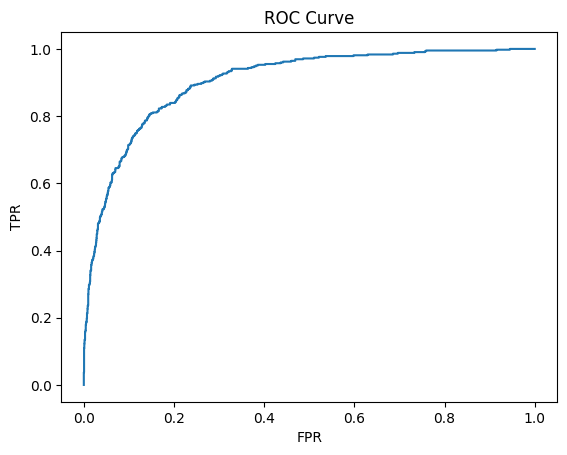

In [27]:
roc_auc = roc_auc_score(y_test, y_test_probs)
print("ROC-AUC:", roc_auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

PR-AUC: 0.7177031561112326


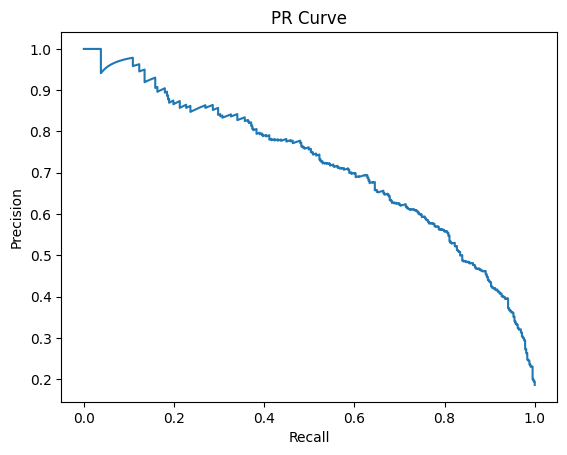

In [28]:
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

plt.plot(recall, precision)
plt.title("PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [29]:
log_model_bal = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    **grid.best_params_
)

log_model_bal.fit(X_train_main_tfidf, y_train_main)

y_probs_bal = log_model_bal.predict_proba(X_test_tfidf)[:, 1]
y_pred_bal = (y_probs_bal >= best_threshold).astype(int)

print("\nCLASS WEIGHT RESULTS")
print(classification_report(y_test, y_pred_bal))



CLASS WEIGHT RESULTS
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1851
           1       0.65      0.66      0.66       423

    accuracy                           0.87      2274
   macro avg       0.79      0.79      0.79      2274
weighted avg       0.87      0.87      0.87      2274



In [30]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_main_tfidf.toarray(),
    y_train_main
)

log_model_smote = LogisticRegression(
    max_iter=2000,
    **grid.best_params_
)

log_model_smote.fit(X_train_smote, y_train_smote)

y_probs_smote = log_model_smote.predict_proba(X_test_tfidf)[:, 1]
y_pred_smote = (y_probs_smote >= best_threshold).astype(int)

print("\nSMOTE RESULTS")
print(classification_report(y_test, y_pred_smote))


SMOTE RESULTS
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1851
           1       0.67      0.64      0.65       423

    accuracy                           0.87      2274
   macro avg       0.79      0.78      0.79      2274
weighted avg       0.87      0.87      0.87      2274

